In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [69]:
df=pd.read_csv('/content/Traffic_Crashes_-_Crashes.csv').drop(columns=['CRASH_RECORD_ID'])
df.head()

,CRASH_DATE_EST_I,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,LANE_CNT,ALIGNMENT,ROADWAY_SURFACE_COND,ROAD_DEFECT,REPORT_TYPE,CRASH_TYPE,INTERSECTION_RELATED_I,NOT_RIGHT_OF_WAY_I,HIT_AND_RUN_I,DAMAGE,DATE_POLICE_NOTIFIED,PRIM_CONTRIBUTORY_CAUSE,SEC_CONTRIBUTORY_CAUSE,STREET_NO,STREET_DIRECTION,STREET_NAME,BEAT_OF_OCCURRENCE,PHOTOS_TAKEN_I,STATEMENTS_TAKEN_I,DOORING_I,WORK_ZONE_I,WORK_ZONE_TYPE,WORKERS_PRESENT_I,NUM_UNITS,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
0,NaN,01/14/2025 12:25:00 PM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,SNOW,DAYLIGHT,SIDESWIPE SAME DIRECTION,DIVIDED - W/MEDIAN (NOT RAISED),NaN,STRAIGHT AND LEVEL,SNOW OR SLUSH,NO DEFECTS,ON SCENE,NO INJURY / DRIVE AWAY,NaN,NaN,Y,"$501 - $1,500",01/14/2025 12:38:00 PM,IMPROPER TURNING/NO SIGNAL,IMPROPER OVERTAKING/PASSING,6352,N,SHERIDAN RD,2433.0,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,12,3,1,41.997808,-87.655770,POINT (-87.655770494712 41.997807727633)
1,NaN,05/23/2025 09:30:00 AM,30,STOP SIGN/FLASHER,UNKNOWN,UNKNOWN,DAYLIGHT,TURNING,DIVIDED - W/MEDIAN (NOT RAISED),NaN,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,NaN,NaN,Y,"OVER $1,500",05/27/2025 10:40:00 AM,IMPROPER OVERTAKING/PASSING,IMPROPER OVERTAKING/PASSING,3555,N,WESTERN AVE,1921.0,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,9,6,5,41.946529,-87.688106,POINT (-87.688106391039 41.946529480518)
2,Y,04/05/2025 08:00:00 PM,30,NO CONTROLS,NO CONTROLS,CLEAR,UNKNOWN,PARKED MOTOR VEHICLE,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,NO INJURY / DRIVE AWAY,NaN,NaN,Y,"OVER $1,500",04/05/2025 09:23:00 PM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,1005,N,DRAKE AVE,1121.0,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,1.0,0.0,20,7,4,41.899325,-87.715074,POINT (-87.715074373867 41.899324573751)
3,NaN,05/23/2025 09:15:00 AM,30,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,PEDALCYCLIST,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,Y,NaN,NaN,$500 OR LESS,05/23/2025 09:16:00 AM,UNABLE TO DETERMINE,UNABLE TO DETERMINE,2901,W,DIVISION ST,1211.0,NaN,NaN,NaN,NaN,NaN,NaN,2,NONINCAPACITATING INJURY,1.0,0.0,0.0,1.0,0.0,2.0,0.0,9,6,5,41.902793,-87.699412,POINT (-87.699412181285 41.902792968177)
4,NaN,01/14/2025 08:00:00 AM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,SNOW,DAYLIGHT,REAR END,FOUR WAY,NaN,STRAIGHT AND LEVEL,WET,NO DEFECTS,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,Y,NaN,NaN,"OVER $1,500",01/14/2025 08:45:00 AM,FOLLOWING TOO CLOSELY,FOLLOWING TOO CLOSELY,4001,W,111TH ST,2211.0,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,8,3,1,41.691207,-87.720555,POINT (-87.720554863466 41.691206664451)


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1031725 entries, 0 to 1031724
Data columns (total 47 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   CRASH_DATE_EST_I               74856 non-null    object 
 1   CRASH_DATE                     1031725 non-null  object 
 2   POSTED_SPEED_LIMIT             1031725 non-null  int64  
 3   TRAFFIC_CONTROL_DEVICE         1031725 non-null  object 
 4   DEVICE_CONDITION               1031725 non-null  object 
 5   WEATHER_CONDITION              1031725 non-null  object 
 6   LIGHTING_CONDITION             1031725 non-null  object 
 7   FIRST_CRASH_TYPE               1031725 non-null  object 
 8   TRAFFICWAY_TYPE                1031725 non-null  object 
 9   LANE_CNT                       199040 non-null   float64
 10  ALIGNMENT                      1031725 non-null  object 
 11  ROADWAY_SURFACE_COND           1031725 non-null  object 
 12  ROAD_DEFECT   

In [71]:
df.shape

(1031725, 47)

In [72]:
df.isna().sum()

,0
CRASH_DATE_EST_I,956869
CRASH_DATE,0
POSTED_SPEED_LIMIT,0
TRAFFIC_CONTROL_DEVICE,0
DEVICE_CONDITION,0
WEATHER_CONDITION,0
LIGHTING_CONDITION,0
FIRST_CRASH_TYPE,0
TRAFFICWAY_TYPE,0
LANE_CNT,832685


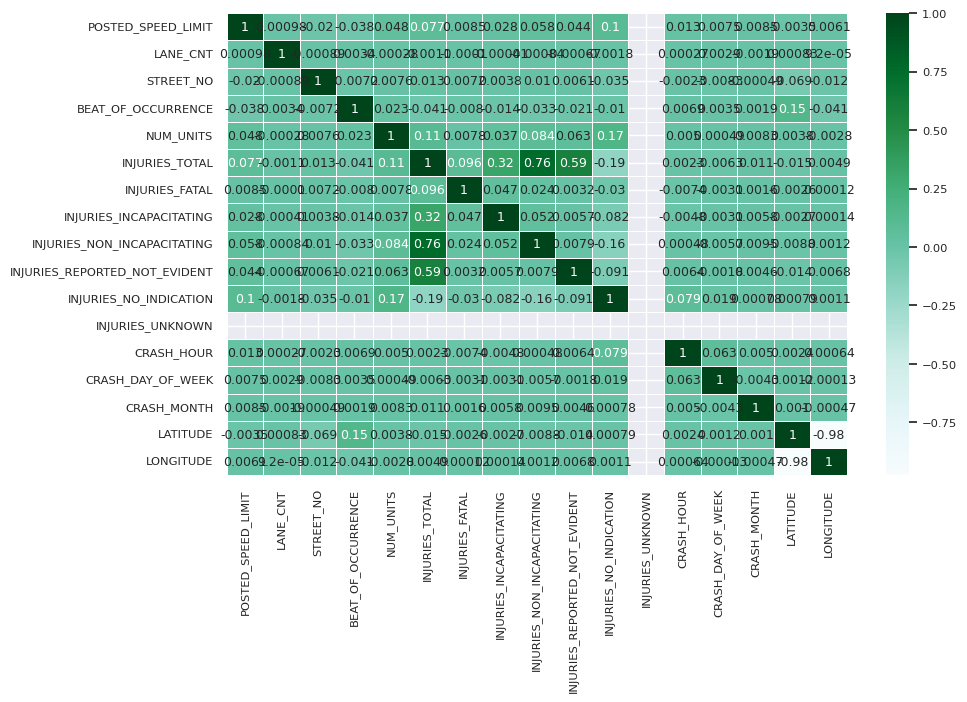

In [76]:
corr=df.corr(numeric_only=True)
sns.set(font_scale=0.75)
sns.heatmap(corr, linewidth=0.5,annot=True,cmap='BuGn');